<a href="https://colab.research.google.com/github/tdineth/Lung-Sound-Analysis/blob/main/mondel2017.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nimalanparameshwaran/icbhi-2017-challenge-respiratory-sound-database")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'icbhi-2017-challenge-respiratory-sound-database' dataset.
Path to dataset files: /kaggle/input/icbhi-2017-challenge-respiratory-sound-database


In [ ]:
file_path="/root/.cache/kagglehub/datasets/nimalanparameshwaran/icbhi-2017-challenge-respiratory-sound-database/versions/1"

**Remove heart sound interference from lung recordings using:**
1. Empirical Mode Decomposition (EMD)
2. Heart sound localization using HHA
3. Remove heart-sound segments
4. Predict missing values using FFT
5. Reconstruct enhanced lung signal


**Pipeline**

ICBHI audio → EMD decomposition → Heart sound detection → Remove HS regions → FFT prediction reconstruction → Enhanced lung signal → MFCC/Spectrogram → CNN or classifier

In [ ]:
!pip install EMD-signal

In [ ]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

from scipy import signal
from PyEMD import EMD

### 1. Load ICBHI recordings

In [ ]:
x, sr = librosa.load(
    f"{file_path}/ICBHI_final_database/101_1b1_Al_sc_Meditron.wav",
    sr=None
    )

print(sr)
print(x.shape)

44100
(882000,)


#### **1. `sr=None`**
This tells librosa:

> “Do NOT resample. Load the audio at its native sampling rate.”

So `sr` becomes whatever sampling rate the WAV file was recorded in — often **4000 Hz**, **8000 Hz**, **11025 Hz**, or **44100 Hz** depending on the stethoscope dataset.

#### **2. `x`**
`x` is a NumPy array containing the audio samples.

- If the file is **mono**, `x.shape` → `(N,)`
- If the file is **stereo**, `x.shape` → `(2, N)` or `(N, 2)` depending on how librosa interprets it  
  (librosa usually mixes to mono unless `mono=False` is set)

Since you didn’t specify `mono=False`, librosa will **convert to mono**, so:

> `x.shape` will almost always be `(num_samples,)`

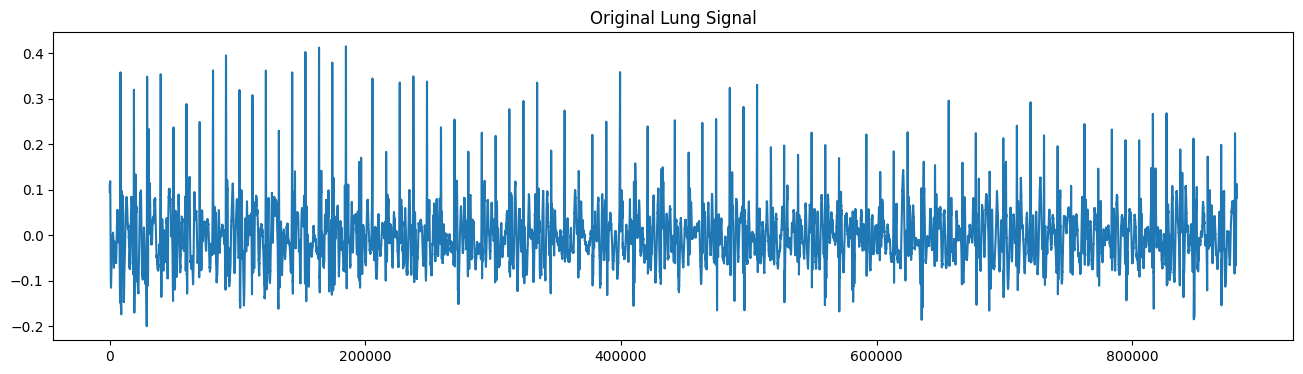

In [ ]:
plt.figure(figsize=(16,4))

plt.plot(x)

plt.title("Original Lung Signal")
plt.show()

### 2. Understand the mathematics of EMD

Paper formula:

Signal:


$$x(n)$$


gets decomposed:

$$
x(n)=\sum_{i=1}^{M} b_i(n)+r_M(n)
$$

where:

$$b_i(n)$$

are intrinsic mode functions.

and:

$$r_M(n)$$

is residual.

The paper repeatedly extracts oscillatory components.



Signal → IMF1 (high frequency) → IMF2 → IMF3 → Residual

The paper states energy decreases with later IMFs.


In [ ]:
#p= x[:30000]

In [ ]:
emd=EMD()

imfs=emd(x)

print(imfs.shape)

KeyboardInterrupt: 

In [ ]:
np.save(
    "lung_imfs.npy",
    imfs
)

In [ ]:
import soundfile as sf
import os

os.makedirs(
    "IMFs",
    exist_ok=True
)

for i in range(len(imfs)):

    sf.write(
        f"IMFs/imf_{i+1}.wav",
        imfs[i],
        sr
    )

In [ ]:
n=len(imfs)

plt.figure(figsize=(15,2*n))

for i in range(n):

    plt.subplot(n,1,i+1)

    plt.plot(imfs[i])

    plt.title(
        f"IMF {i+1}"
    )

plt.tight_layout()
plt.show()

- early IMFs contain noise
- middle IMFs contain respiratory structure
- lower IMFs contain heart components